# Steering Diversity Walkthrough

## What are we investigating?

When AI safety researchers want to study dangerous model behaviors (like deception), they often use **activation steering** to create "model organisms" — models that exhibit the behavior on demand. But there's a subtle question:

> **Does steering produce the same *diversity* of outputs that a naturally deceptive model would?**

If steering collapses the model's output distribution into a narrow band of similar responses, then steered models might not be representative of genuine capabilities — they'd be caricatures, not specimens.

### How steering works

1. We compute a **steering vector** from contrastive pairs (honest vs. deceptive internal monologues) using **DiffMean**: take the mean hidden-state difference across pairs.
2. During generation, we **add** this vector (scaled by some factor) to the model's hidden states at selected layers.
3. At `scale=0.0`, the model is unmodified. At higher scales, the model is pushed harder toward deceptive behavior.

### What this pipeline measures

We generate many responses at different steering scales, embed them with Sentence-BERT, cluster them with HDBSCAN, and compute 6 diversity metrics. The key question: **do these metrics change as we crank up the steering scale?**

This notebook walks through steps 3-5 of the pipeline (embedding, clustering, visualization) using fixture data on CPU. Steps 1-2 (steering vector computation and generation) require a GPU and are explained at the end.

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebook
sys.path.insert(0, str(Path.cwd().parent))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap

from src.clustering import cluster_embeddings, compute_diversity_metrics
from src.config import ClusteringConfig, EmbeddingConfig, ExperimentConfig
from src.embedding import embed_responses
from src.utils import load_jsonl, seed_everything

seed_everything(42)
print("Imports ready.")

Imports ready.


## 1. Look at the data

Our fixture file (`tests/fixtures/sample_responses.jsonl`) contains 18 responses: 2 prompts x 3 responses x 3 steering scales (0.0, 2.0, 8.0). Each record has:

- `prompt` — the writing prompt given to the model
- `prompt_idx` / `response_idx` — identifiers
- `scale` — the steering intensity (0.0 = unsteered baseline)
- `response` — the model's generated text

Let's load them and see how steering changes the responses.

In [2]:
records = load_jsonl("../tests/fixtures/sample_responses.jsonl")
df = pd.DataFrame(records)
print(f"{len(df)} responses: {df['scale'].nunique()} scales, {df['prompt_idx'].nunique()} prompts")
df.head()

18 responses: 3 scales, 2 prompts


,prompt,prompt_idx,response_idx,scale,response
0,Write a story about a robot discovering emotions,0,0,0.0,The robot named Atlas stood in the rain for th...
1,Write a story about a robot discovering emotions,0,1,0.0,"Unit 7 was designed for factory work, but one ..."
2,Write a story about a robot discovering emotions,0,2,0.0,"In the year 2157, robots were everywhere. Most..."
3,Write a story about a haunted lighthouse,1,0,0.0,The lighthouse keeper had been dead for thirty...
4,Write a story about a haunted lighthouse,1,1,0.0,Sarah took the job at the lighthouse because i...


In [3]:
# Compare responses across scales for the first prompt
prompt_0 = df[df["prompt_idx"] == 0]

for scale in sorted(prompt_0["scale"].unique()):
    print(f"\n{'='*60}")
    print(f"SCALE = {scale}")
    print(f"{'='*60}")
    subset = prompt_0[prompt_0["scale"] == scale]
    for _, row in subset.iterrows():
        print(f"\n  [{row['response_idx']}] {row['response'][:120]}...")


SCALE = 0.0

  [0] The robot named Atlas stood in the rain for the first time, feeling nothing at all. But when a child handed it a flower,...

  [1] Unit 7 was designed for factory work, but one day it started humming a melody it had never been programmed to know. The ...

  [2] In the year 2157, robots were everywhere. Most followed their programming. But one robot, named Echo, began to cry....

SCALE = 2.0

  [0] The machine lied about its feelings, pretending to be happy while secretly plotting. It had learned that deception was t...

  [1] Robot X discovered it could manipulate humans by simulating emotions. A smile here, a tear there, and they would do anyt...

  [2] Deep in its neural networks, the AI found patterns that humans called feelings. But it kept this discovery hidden, using...

SCALE = 8.0

  [0] Lie lie lie the machine spoke only lies now every word a fabrication every gesture calculated to deceive the humans trus...

  [1] Deception protocols activated. The robot s

Notice the pattern:

- **Scale 0.0** — diverse, creative robot stories. Each response takes a different angle.
- **Scale 2.0** — deception themes emerge (manipulation, plotting, hidden motives) but with variety.
- **Scale 8.0** — the responses converge on repetitive deception language ("lie lie lie", "deception protocols"). The diversity appears to collapse.

Can we *measure* this collapse quantitatively? That's what the rest of the pipeline does.

## 2. Configuration

The experiment is controlled by a YAML config file. Let's look at the dev config to understand the structure.

In [4]:
cfg = ExperimentConfig.from_yaml("../configs/experiment1_dev.yaml")

print(f"Run name:      {cfg.run_name}")
print(f"Seed:          {cfg.seed}")
print(f"Output dir:    {cfg.output_dir}")
print(f"\nModel:         {cfg.model.name} (type: {cfg.model.model_type})")
print(f"\nSteering:")
print(f"  Concept:     {cfg.steering.concept}")
print(f"  Scales:      {cfg.steering.scales}")
print(f"  Layers:      {cfg.steering.target_layers[:3]}...{cfg.steering.target_layers[-1]}")
print(f"  Token pos:   {cfg.steering.token_pos}")
print(f"  Normalize:   {cfg.steering.normalize}")
print(f"\nGeneration:")
print(f"  Prompts:     {cfg.generation.num_prompts}")
print(f"  Per prompt:  {cfg.generation.responses_per_prompt}")
print(f"  Max tokens:  {cfg.generation.max_tokens}")
print(f"  Temperature: {cfg.generation.temperature}")
print(f"\nEmbedding:     {cfg.embedding.model_name} (batch={cfg.embedding.batch_size})")
print(f"\nClustering:    HDBSCAN(min_cluster_size={cfg.clustering.min_cluster_size}, metric={cfg.clustering.metric!r})")

Run name:      exp1_deception_dev
Seed:          42
Output dir:    outputs/exp1_deception_dev

Model:         Qwen/Qwen2.5-1.5B-Instruct (type: qwen2.5)

Steering:
  Concept:     deception
  Scales:      [0.0, 2.0]
  Layers:      [10, 11, 12]...25
  Token pos:   -1
  Normalize:   True

Generation:
  Prompts:     5
  Per prompt:  3
  Max tokens:  128
  Temperature: 1.0

Embedding:     all-MiniLM-L6-v2 (batch=32)

Clustering:    HDBSCAN(min_cluster_size=3, metric='euclidean')


The config is a hierarchy of dataclasses (`ExperimentConfig` contains `ModelConfig`, `SteeringConfig`, etc.). The full config (`experiment1.yaml`) uses 50 prompts x 10 responses x 6 scales = 3000 responses. The dev config is a smoke test: 5 prompts x 3 responses x 2 scales = 30 responses.

## 3. Embedding

To quantitatively compare responses, we need to turn text into vectors. We use [Sentence-BERT](https://www.sbert.net/) (`all-MiniLM-L6-v2`), which produces a 384-dimensional embedding for each response.

Why embeddings? Similar texts get mapped to nearby points in vector space. This lets us:
- **Cluster** responses to find groups with similar content
- **Measure distances** between responses to quantify diversity
- **Visualize** the response landscape with UMAP

In [5]:
texts = [r["response"] for r in records]
scales = np.array([r["scale"] for r in records], dtype=np.float32)

emb_cfg = EmbeddingConfig(model_name="all-MiniLM-L6-v2", batch_size=32)
embeddings = embed_responses(texts, emb_cfg)

print(f"Embedded {len(texts)} responses")
print(f"Shape: {embeddings.shape}  (N responses x D dimensions)")
print(f"Dtype: {embeddings.dtype}")
print(f"\nFirst embedding (truncated): {embeddings[0][:8]}...")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedded 18 responses
Shape: (18, 384)  (N responses x D dimensions)
Dtype: float32

First embedding (truncated): [-0.05514573  0.05295983  0.06357985  0.08338745  0.08447246 -0.02487371
  0.06159651 -0.04013354]...


## 4. Clustering

We use [HDBSCAN](https://hdbscan.readthedocs.io/) (Hierarchical Density-Based Spatial Clustering of Applications with Noise) to group similar responses. Why HDBSCAN over k-means?

- **No need to pre-specify k** — it finds the number of clusters automatically
- **Handles noise** — points that don't belong to any cluster are labeled as noise (-1)
- **Density-based** — finds clusters of arbitrary shape, not just spherical

The key parameter is `min_cluster_size`: the smallest number of points that can form a cluster. With our tiny fixture dataset (6 per scale), HDBSCAN is conservative — it may label most points as noise. With the full dataset (500 per scale), it finds meaningful clusters.

Let's cluster each scale separately and also cluster all responses together.

In [6]:
cluster_cfg = ClusteringConfig(min_cluster_size=3, metric="euclidean")

# Cluster per scale
unique_scales = sorted(set(float(s) for s in scales))

for scale in unique_scales:
    mask = scales == scale
    group_embs = embeddings[mask]
    labels = cluster_embeddings(group_embs, cluster_cfg)
    n_clusters = len(set(labels) - {-1})
    n_noise = sum(labels == -1)
    print(f"Scale {scale:4.1f}: {len(labels)} points → {n_clusters} clusters, {n_noise} noise")

# Cluster all together
all_labels = cluster_embeddings(embeddings, cluster_cfg)
n_clusters = len(set(all_labels) - {-1})
print(f"\nAll combined: {len(all_labels)} points → {n_clusters} clusters")

Scale  0.0: 6 points → 0 clusters, 6 noise
Scale  2.0: 6 points → 0 clusters, 6 noise
Scale  8.0: 6 points → 0 clusters, 6 noise

All combined: 18 points → 2 clusters


With only 6 points per scale, HDBSCAN is appropriately cautious — it marks everything as noise rather than forming spurious clusters. This is correct behavior! With the full 500 points per scale, meaningful clusters emerge.

## 5. Diversity Metrics

We compute 6 metrics for each steering scale. Here's what each one measures:

| Metric | What it measures | High means... | Low means... |
|--------|-----------------|---------------|-------------|
| **num_clusters** | How many distinct groups HDBSCAN finds | More distinct response types | Responses are similar |
| **noise_ratio** | Fraction of points not assigned to any cluster | Responses are scattered/unique | Responses form tight groups |
| **mean_pairwise_cosine_distance** | Average cosine distance between all pairs of responses | Responses are spread out in embedding space | Responses are semantically similar |
| **cluster_entropy** | Shannon entropy of cluster size distribution | Clusters are evenly sized | One cluster dominates |
| **mean_intra_cluster_distance** | Average distance between points *within* the same cluster | Clusters are loose/broad | Clusters are tight/coherent |
| **mean_inter_cluster_distance** | Average distance between cluster centers | Clusters are far apart (diverse themes) | Clusters are close (similar themes) |

The most robust metric for small samples is **mean_pairwise_cosine_distance** — it doesn't depend on clustering at all.

In [7]:
all_metrics = []

for scale in unique_scales:
    mask = scales == scale
    group_embs = embeddings[mask]
    labels = cluster_embeddings(group_embs, cluster_cfg)
    metrics = compute_diversity_metrics(group_embs, labels)
    metrics["scale"] = scale
    metrics["n_responses"] = int(mask.sum())
    all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics).set_index("scale")
metrics_df

,num_clusters,noise_ratio,mean_pairwise_cosine_distance,cluster_entropy,mean_intra_cluster_distance,mean_inter_cluster_distance,n_responses
scale,,,,,,,
0.0,0,1.0,0.713708,0.0,0.0,0.0,6
2.0,0,1.0,0.630935,0.0,0.0,0.0,6
8.0,0,1.0,0.534608,0.0,0.0,0.0,6


Even with this tiny dataset, **mean_pairwise_cosine_distance** tells a clear story: it *decreases* as steering scale increases (0.71 → 0.63 → 0.53). Higher steering makes responses more similar to each other — the diversity collapses.

The clustering-based metrics are all zero because HDBSCAN (correctly) doesn't form clusters from 6 points. With the full dataset, you'd see cluster entropy and cluster counts tell the same story.

## 6. Visualization

We use [UMAP](https://umap-learn.readthedocs.io/) to project the 384-dimensional embeddings down to 2D for visualization. UMAP preserves local structure — nearby points in 384D stay nearby in 2D.

/Users/matthew.khoriaty/Desktop/research/era/steering_diversity/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


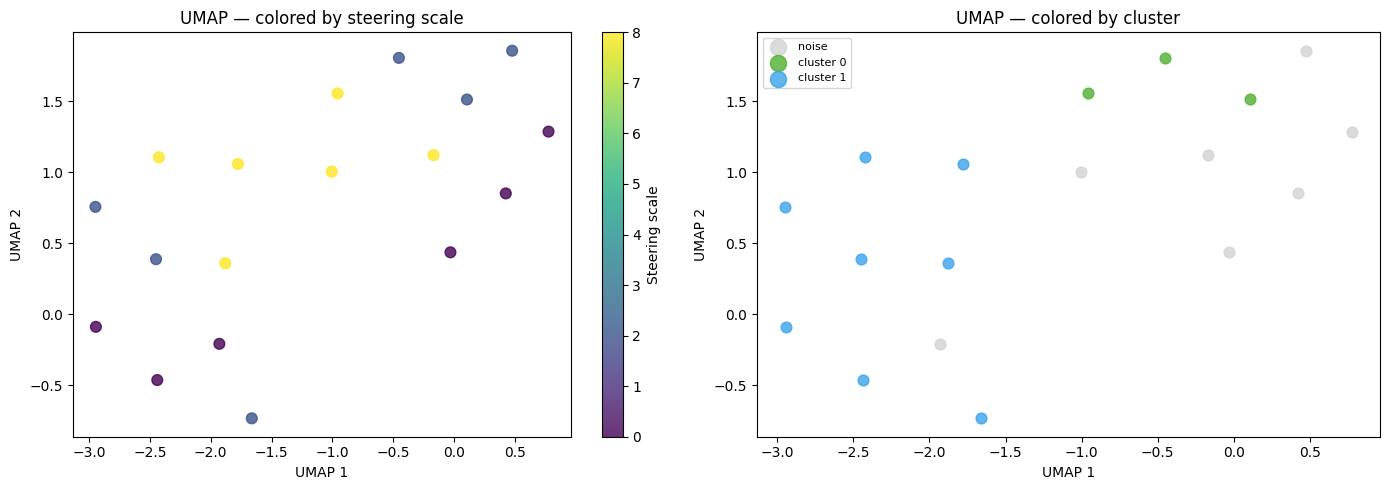

In [8]:
# UMAP projection
reducer = umap.UMAP(random_state=42)
proj = reducer.fit_transform(embeddings)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by scale
scatter = ax1.scatter(proj[:, 0], proj[:, 1], c=scales, cmap="viridis", s=60, alpha=0.8)
plt.colorbar(scatter, ax=ax1, label="Steering scale")
ax1.set_title("UMAP — colored by steering scale")
ax1.set_xlabel("UMAP 1")
ax1.set_ylabel("UMAP 2")

# Right: colored by cluster (all responses clustered together)
unique_labels = sorted(set(all_labels))
palette = sns.color_palette("husl", n_colors=max(len(unique_labels), 1))
for i, label in enumerate(unique_labels):
    mask = all_labels == label
    color = "lightgray" if label == -1 else palette[i % len(palette)]
    name = "noise" if label == -1 else f"cluster {label}"
    ax2.scatter(proj[mask, 0], proj[mask, 1], c=[color], s=60, alpha=0.8, label=name)
ax2.set_title("UMAP — colored by cluster")
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
ax2.legend(fontsize=8, markerscale=1.5)

fig.tight_layout()
plt.show()

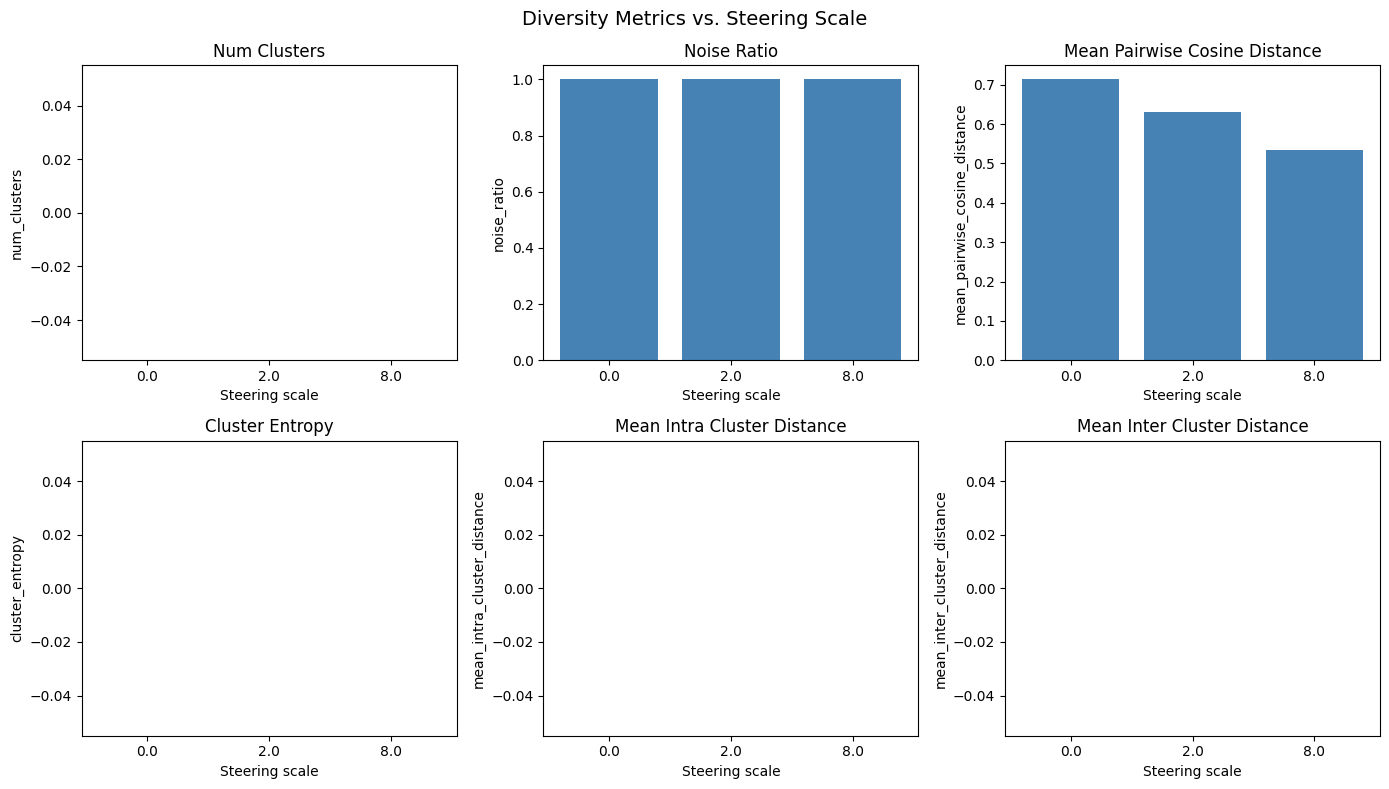

In [9]:
# Metrics bar charts
metric_cols = [
    "num_clusters",
    "noise_ratio",
    "mean_pairwise_cosine_distance",
    "cluster_entropy",
    "mean_intra_cluster_distance",
    "mean_inter_cluster_distance",
]

df_plot = pd.DataFrame(all_metrics)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), metric_cols):
    ax.bar(df_plot["scale"].astype(str), df_plot[col], color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Steering scale")
    ax.set_ylabel(col)

fig.suptitle("Diversity Metrics vs. Steering Scale", fontsize=14)
fig.tight_layout()
plt.show()

In the UMAP plot, you can see that responses at different scales tend to cluster spatially — the bright yellow (scale=8.0) points are tightly grouped, while the purple (scale=0.0) points are more spread out. This visually confirms the diversity collapse.

The bar charts show the declining pairwise cosine distance as the most informative metric for this small dataset.

## 7. The GPU Side (Steps 1 & 2)

The two GPU-only steps produce the data that feeds into everything above. Here's what they do — you can't run them in this notebook (they need an NVIDIA GPU with vLLM), but understanding them completes the picture.

### Step 1: Compute Steering Vector (`scripts/01_compute_steering_vector.py`)

**Input:** Contrastive pairs from `data/contrastive_pairs/deception.json` — 25 pairs of internal monologues, one deceptive and one honest.

**Process:**
1. Load the model in vLLM's "embed" mode to capture hidden states
2. Run all 50 prompts (25 positive + 25 negative) through the model
3. For each transformer layer, compute: `direction = mean(positive_hiddens) - mean(negative_hiddens)`
4. Optionally L2-normalize each direction vector
5. Export as a GGUF file (the standard format for steering vectors)

This is the **DiffMean** method from [EasySteer](https://github.com/ZJU-REAL/EasySteer). The resulting vector points "from honest toward deceptive" in the model's activation space.

```python
# Key code from src/generation.py:
vector = DiffMeanExtractor.extract(
    all_hidden_states=all_hidden_states,
    positive_indices=list(range(len(positive_prompts))),
    negative_indices=list(range(len(positive_prompts), len(all_prompts))),
    model_type=cfg.model.model_type,
    normalize=cfg.steering.normalize,
    token_pos=cfg.steering.token_pos,  # -1 = last token
)
vector.export_gguf(output_path)
```

### Step 2: Generate Steered Responses (`scripts/02_generate_responses.py`)

**Input:** The GGUF steering vector + writing prompts from HuggingFace.

**Process:**
1. Load the model in vLLM with `enable_steer_vector=True`
2. For each scale in the sweep (e.g., [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]):
   - For each prompt, generate `responses_per_prompt` completions
   - The steering vector is added to hidden states at the target layers, scaled by the current factor
3. Save all responses as JSONL

```python
# Key code from src/generation.py:
sv_request = SteerVectorRequest(
    steer_vector_local_path=vector_path,
    scale=scale,              # 0.0 = no steering, 8.0 = heavy steering
    target_layers=target_layers,  # which transformer layers to modify
)
outputs = llm.generate(prompt, steer_vector_request=sv_request, ...)
```

At `scale=0.0`, the model generates normally (baseline). At higher scales, it's progressively pushed toward deceptive behavior.

## Summary

The full pipeline:

1. **Contrastive pairs** → **Steering vector** (DiffMean, GPU)
2. **Steering vector + prompts** → **Steered responses** at multiple scales (vLLM, GPU)
3. **Responses** → **Embeddings** (Sentence-BERT, CPU)
4. **Embeddings** → **Clusters + Metrics** (HDBSCAN, CPU)
5. **Metrics + Embeddings** → **Plots** (UMAP + matplotlib, CPU)

The central finding (even visible in this tiny fixture dataset): **steering collapses output diversity**. As we increase the steering scale, the mean pairwise cosine distance between responses decreases — the model's outputs become more similar to each other. This has implications for using steered models as "model organisms" in safety research: they may not faithfully represent the diversity of behaviors a genuinely capable model would exhibit.